In [313]:
import numpy as np
import pandas as pd

from tqdm import tqdm

from numpy.typing import NDArray
from typing import Iterator, List, Callable, Any

import matplotlib.pyplot as plt

from functools import partial
from dataclasses import dataclass
from collections import defaultdict

from scipy.optimize import minimize, NonlinearConstraint
from sklearn.datasets import make_spd_matrix

import time

import cvxpy as cp

### Задача оптимизации

$\min\{ (x-\mu_0)^\top A (x-\mu_0) : ||x||_2^2 \leq 1 \}$, где
* $x \in \mathbb{R}^n$, $A$ - симметричная, положительно определенная матрица
* $\mu_0 = (1,1,\dots,1)^\top \in \mathbb{R}^n$

### Функция
$f(x) = (x-\mu_0)^\top A (x-\mu_0)$

Градиент имеет вид: $\nabla x^\top A x = (A+A^\top)x =$ [при симметричной матрице $A$] $= 2Ax$

$\nabla f = 2A(x-\mu_0)$

$\nabla^2 f = 2A \cdot I$

#### Оценка на L-Lipschitz

$\lambda_{max}(\nabla^2f) \leq L$

$L = \max(diag(\nabla^2 f)) = \max(diag(2AI)) = 2\max(diag(A))$

#### Оценка на $\alpha$-str cvx

$\nabla^2 f \leq \alpha \cdot I$

$\alpha = \min(diag(\nabla^2 f)) = \min(diag(2AI)) = 2\min(diag(A))$

In [314]:
def function(x: NDArray, A: NDArray, mu: NDArray) -> float:
    return (x - mu).T @ A @ (x - mu)


def grad_function(x: NDArray, A: NDArray, mu: NDArray) -> NDArray:
    return 2 * A @ (x - mu)


def get_Lipschitz_constant(A: NDArray) -> float:
    return np.linalg.eigvals(2 * A).max()


def get_str_cvx_constant(A: NDArray) -> float:
    return np.linalg.eigvals(2 * A).min()

### Ограничение
$c(x) = ||x||_2^2 = \sum_{i=1}^{n} x_i^2 \leq 1$, где $x = (x_1, x_2, \dots, x_n)^\top \in \mathbb{R}^n$

$\nabla c(x) = (2x_1, 2x_2, \dots, 2x_n)^\top = 2x \in \mathbb{R}^n$

In [315]:
def constraint(x: NDArray) -> float:
    return np.sum(np.power(x, 2))


def grad_constraint(x: NDArray) -> NDArray:
    return 2 * x

### 1. Исследование на выпуклость

При всех вводных задача является выпуклой, если выпуклой будет $f(x)$.

$f(\lambda x + (1− \lambda)y) \leq \lambda f(x) + (1− \lambda)f(y)$, где $0 \leq \lambda \leq 1$

In [316]:
n = 100
A = make_spd_matrix(n)
mu = np.ones(n)

f = partial(function, A=A, mu=mu)

x = np.random.random(n)
y = np.random.random(n)


def is_convex(t: float):
    return f(t * x + (1 - t) * y) <= t * f(x) + (1 - t) * f(y)


all(is_convex(t) for t in np.linspace(0, 1, 10))

True

### 2. Генерация тестовой выборки

In [317]:
@dataclass
class Experiment:
    A: NDArray
    x: NDArray

    real_min_x: NDArray = None

    result: Any = None

    @staticmethod
    def create(A: NDArray, n: int):
        x = np.random.random(n)
        return Experiment(A.copy(), x)


class TestCases:
    def __init__(self, num_range: Iterator[int], num_experiments: int, num_tries: int) -> None:
        self.experiments: List[Experiment] = []

        for n in tqdm(num_range):
            for _ in range(num_experiments):
                A = make_spd_matrix(n)
                for _ in range(num_tries):
                    self.experiments.append(Experiment.create(A, n))

In [318]:
def exact_search(f: Callable[[NDArray], NDArray], x_init: NDArray, tol: float = 1e-4) -> NDArray:
    nl_constraint = NonlinearConstraint(constraint, lb=-np.inf, ub=1)
    result = minimize(f, x_init, method='cobyqa', constraints=nl_constraint, tol=tol)
    if result is None:
        return None
    return result.x

In [319]:
def exact_search_cvxpy(A: NDArray, mu: NDArray):
    x = cp.Variable(A.shape[0])
    optimization_func = cp.quad_form(x=(x - mu), P=A)
    objective = cp.Minimize(optimization_func)

    constraints = [
        cp.sum_squares(x) <= 1
    ]

    problem = cp.Problem(objective, constraints)
    problem.solve()
    return x.value

In [320]:
test_cases = TestCases(range(10, 101, 10), 100, 10)

100%|██████████| 10/10 [00:01<00:00,  9.09it/s]


In [321]:
def check_optimality(x: NDArray, A: NDArray, mu: NDArray) -> bool:
    return grad_constraint(x) @ -grad_function(x, A, mu) >= 0

In [322]:
for exp in tqdm(test_cases.experiments):
    n = exp.A.shape[0]
    exp.real_min_x = exact_search_cvxpy(exp.A, np.ones(n))
    assert check_optimality(exp.real_min_x, exp.A, np.ones(n))

 39%|███▉      | 3894/10000 [00:12<00:19, 318.02it/s]


KeyboardInterrupt: 

### 3. Gadient descent for **strongly convex** and **Lipschitz** functions



We say that $f : \mathcal{X} \to \mathbb{R}$ is $\alpha$-strongly convex if it satisfies the following improved subgradient inequality:

$f(x) - f(y) \leq \nabla f(x)^\top (x - y) - \dfrac{\alpha}{2} \| x - y \|^2$

In [ ]:
def projection_operator(x):
    """Проекция точки x на единичный шар (‖x‖₂² <= 1)."""
    norm = np.linalg.norm(x)
    return x if norm <= 1.0 else x / norm

In [ ]:
n = 2
m = n // 2
A = make_spd_matrix(n)
mu = np.ones(n)

f = partial(function, A=A, mu=mu)
grad_f = partial(grad_function, A=A, mu=mu)

solver_f = partial(exact_search_cvxpy, A=A, mu=mu)

L = get_Lipschitz_constant(A)
alpha = get_str_cvx_constant(A)
alpha, L

(np.float64(0.5182601741462689), np.float64(4.60077692590214))

In [ ]:
T = 100


def nu(t: int, alpha: float):
    assert t >= 1
    return 2.0 / alpha / (t + 1)


history = []

x = projection_operator(2 * np.random.random(2) - 1)
x_prev = [x]

x_opt = solver_f()
f_opt = f(x_opt)

history.append([x[0], x[1], f(x)])

for k in range(1, T + 1):   
    y = x - nu(k, alpha) * grad_f(x)
    x = projection_operator(y)
    x_prev.append(x.copy())

    f_cur = f(x)

    if f_cur - f_opt <= 1e-4:
        T = k
        break
    history.append([x[0], x[1], f(x)])

history = np.array(history)
history[-1], f_opt

(array([0.90446   , 0.42655845, 0.10184969]), np.float64(0.09942647002441177))

In [ ]:
better_history = []
for i in range(1, len(history)):
    x0, y0, z0 = history[i - 1]
    x1, y1, z1 = history[i]

    points = np.linspace(start=(x0, y0), stop=(x1, y1), num=10)
    better_history.extend([(*pt, f(pt)) for pt in points])

better_history = np.array(better_history)

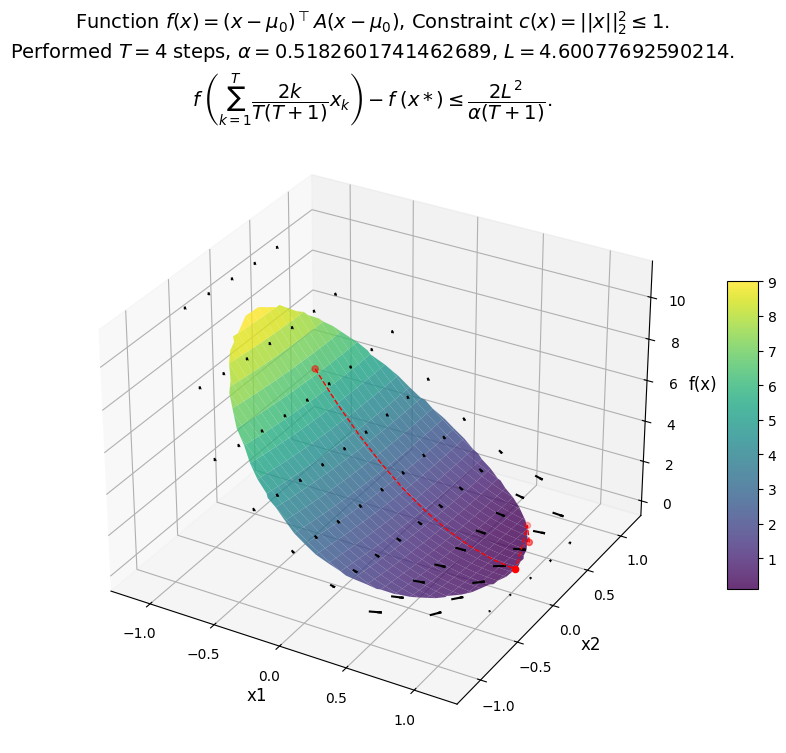

In [ ]:
# Создаём сетку данных
x1 = np.linspace(-2, 2, 200)
x2 = np.linspace(-2, 2, 200)
X1, X2 = np.meshgrid(x1, x2)

# Вычисляем функцию для каждой точки сетки
Z = np.zeros_like(X1)
for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
        x = np.array([X1[i,j], X2[i,j]])
        if constraint(x) > 1:
            Z[i,j] = None
            X1[i,j] = None
            X2[i,j] = None
            continue
        Z[i,j] = f(x)

# Строим 3D график
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d', computed_zorder=False)
surf = ax.plot_surface(X1, X2, Z, cmap='viridis', alpha=0.8)

x1 = np.linspace(-2, 2, 15)
x2 = np.linspace(-2, 2, 15)
X1, X2 = np.meshgrid(x1, x2)
Z = np.zeros_like(X1)
for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
        x = np.array([X1[i,j], X2[i,j]])
        if constraint(x) > 2:
            Z[i,j] = None
            X1[i,j] = None
            X2[i,j] = None
            continue
        Z[i,j] = f(x)

U = np.zeros_like(X1)
V = np.zeros_like(X1)
W = np.zeros_like(X1)
for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
        U[i,j], V[i,j] = -grad_f(np.array([X1[i,j], X2[i,j]]))
        W[i,j] = -f(np.array([U[i,j], V[i,j]]))

ax.quiver(X1, X2, Z, U, V, W, length=0.1, normalize=True, colors='k')

ax.plot(better_history[:,0], better_history[:,1], better_history[:,2], 'r--', linewidth=1)
ax.scatter(history[:,0], history[:,1], history[:,2], c='r', marker='o')

# Настройка отображения
ax.set_xlabel('x1', fontsize=12)
ax.set_ylabel('x2', fontsize=12)
ax.set_zlabel('f(x)', fontsize=12)

function_descr = r'Function $f(x) = (x - \mu_0)^\top A(x - \mu_0)$'
constraint_descr = r'Constraint $c(x) = ||x||^2_2 \leq 1$'
steps_descr = f'Performed $T={T}$ steps'
constants_descr = rf'$\alpha={alpha}$, $L={L}$'
convergence_descr = r'$f\;\left(\sum^T_{k=1}\dfrac{2k}{T(T + 1)}x_k \right)-f\;(x*) \leq \dfrac{2L^2}{\alpha(T + 1)}$'

ax.set_title(f'{function_descr}, {constraint_descr}.\n{steps_descr}, {constants_descr}.\n{convergence_descr}.', fontsize=14)
plt.colorbar(surf, shrink=0.5, aspect=10)

plt.show()

In [ ]:
@dataclass
class GradDescentResult:
    x: NDArray
    y: float
    time: float
    iterations: int
    accuracy: NDArray
    history: NDArray


def grad_descent(f: Callable[[NDArray], NDArray],
                 grad_f: Callable[[NDArray], NDArray],
                 solver_f: Callable[[], None],
                 learning_rate: Callable[[int], float],
                 x_init: NDArray,
                 T: int = 100,
                 eps: float = 1e-4):    

    x_opt = solver_f()
    f_opt = f(x_opt)

    start_time = time.time()

    x = projection_operator(x_init)
    x_prev = [x]

    for k in range(1, T + 1):

        y = x - learning_rate(k) * grad_f(x)
        x = projection_operator(y)
        x_prev.append(x.copy())

        f_cur = f(x)

        if f_cur - f_opt <= eps:
            T = k
            break

    end_time = time.time();

    return GradDescentResult(
        x=x,
        y=f(x),
        time=end_time-start_time,
        iterations=T,
        accuracy=(np.array([f(x) for x in x_prev[1:]]) - f(x_opt)) ** 2,
        history=x_prev
    )

### Запуск

In [ ]:
results_iters = defaultdict(list)
results_time = defaultdict(list)

for exp in tqdm(test_cases.experiments):
    A = exp.A
    n = A.shape[0]
    mu = np.ones(n)

    f = partial(function, A=A, mu=mu)
    grad_f = partial(grad_function, A=A, mu=mu)

    solver_f = partial(exact_search_cvxpy, A=A, mu=mu)

    L = get_Lipschitz_constant(A)
    alpha = get_str_cvx_constant(A)

    exp.result = grad_descent(f, grad_f, solver_f, partial(nu, alpha=alpha), exp.x, T=1000, eps=1e-7)

    if exp.result.iterations == 1000:
        continue

    results_iters[n].append(exp.result.iterations)
    results_time[n].append(exp.result.time)

100%|██████████| 10000/10000 [02:59<00:00, 55.84it/s]


In [ ]:
for n in results_iters.keys():
    print(f'[n={n}] avg iters = {np.mean(results_iters[n])}     avg time = {np.mean(results_time[n])}')

[n=10] avg iters = 51.428     avg time = 0.0005244450569152832
[n=20] avg iters = 151.277     avg time = 0.001523996114730835
[n=30] avg iters = 213.64772727272728     avg time = 0.0022076132622632113
[n=40] avg iters = 242.3988764044944     avg time = 0.0029990429288885567
[n=50] avg iters = 343.11392405063293     avg time = 0.004508670070503332
[n=60] avg iters = 364.22985074626865     avg time = 0.00504186651599941
[n=70] avg iters = 334.9016393442623     avg time = 0.004921711859155874
[n=80] avg iters = 359.7692307692308     avg time = 0.005693176342890812
[n=90] avg iters = 294.42857142857144     avg time = 0.005121422665459769
[n=100] avg iters = 367.5018867924528     avg time = 0.006758075390221938


### Зависимоть точности от числа итераций.

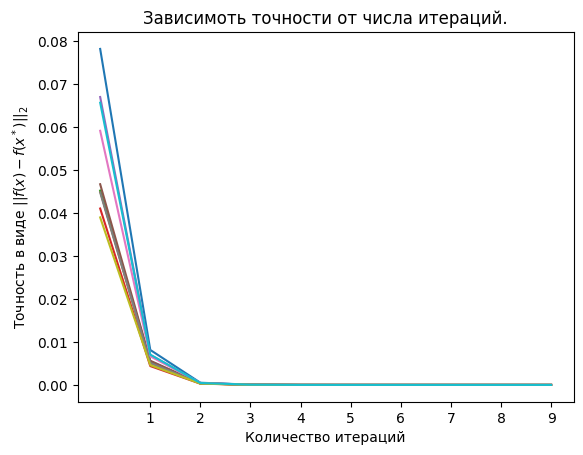

In [ ]:
n = 10
A = make_spd_matrix(n)
mu = np.ones(n)

f = partial(function, A=A, mu=mu)
grad_f = partial(grad_function, A=A, mu=mu)

solver_f = partial(exact_search_cvxpy, A, mu)

L = get_Lipschitz_constant(A)
alpha = get_str_cvx_constant(A)

max_iters = 0
for _ in range(10):

    x_init = np.random.random(n)
    result = grad_descent(f, grad_f, solver_f, partial(nu, alpha=alpha), x_init, T=100, eps=1e-5)
    
    max_iters = max(max_iters, len(result.accuracy))
    plt.plot(range(len(result.accuracy)), result.accuracy)

plt.title(r'Зависимоть точности от числа итераций.')
plt.ylabel('Точность в виде $||f(x) - f(x^*)||_2$')
plt.xlabel('Количество итераций')
plt.xticks(range(1, max_iters))
plt.show();

### Зависимоть скорости сходимости от соотношения минимального и максимального собственных чисел матрицы $A$.

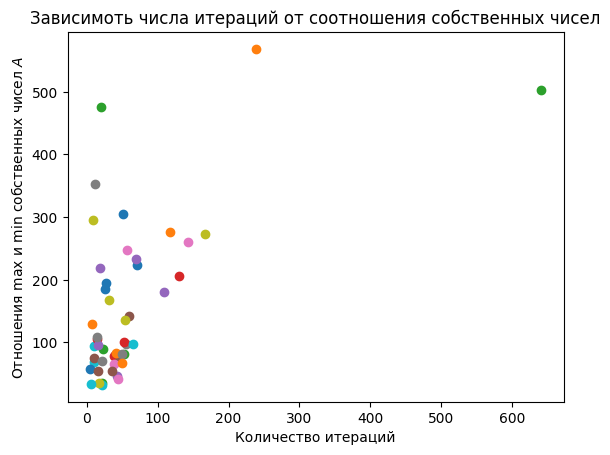

In [ ]:
for _ in range(50):
    # Генерация рандомной матрицы
    n = 10
    A = make_spd_matrix(n)
    mu = np.ones(n)

    f = partial(function, A=A, mu=mu)
    grad_f = partial(grad_function, A=A, mu=mu)

    solver_f = partial(exact_search_cvxpy, A=A, mu=mu)

    L = get_Lipschitz_constant(A)
    alpha = get_str_cvx_constant(A)

    eigenvalues = np.linalg.eigvals(A)
    ratio = max(eigenvalues) / min(eigenvalues)

    # Оптимизация
    iters = []
    for _ in range(10):
        x_init = np.random.random(n)
        result = grad_descent(f, grad_f, solver_f, partial(nu, alpha=alpha), x_init, T=1000, eps=1e-7)

        iters.append(result.iterations)

    plt.scatter(np.mean(iters), ratio)

plt.title(r'Зависимоть числа итераций от соотношения собственных чисел')
plt.ylabel('Отношения max и min собственных чисел $A$')
plt.xlabel('Количество итераций')
plt.show();

### LAB2. SGD

### Визуализация

In [ ]:
"""
def stohastic_grad_function(x: NDArray, A: NDArray, mu: NDArray, m: int) -> NDArray:
    sgd_result = np.zeros(A.shape[0])
    
    for idx in np.random.randint(low=0, high=A.shape[0], size=m):
        grad_i = 2 * np.dot(A[idx], x - mu)
        sgd_result[idx] += grad_i# * A.shape[0]

    return sgd_result / m
"""

In [393]:
def stohastic_grad_function(x: NDArray, A: NDArray, mu: NDArray, m: int) -> NDArray:
    grad_full = 2 * A.dot(x - mu)
    
    n = x.shape[0]
    stoch_grad = np.zeros_like(x)
    for j in range(m):
        i = np.random.randint(0, n)          
        stoch_grad[i] += n * grad_full[i]    
    return stoch_grad / m 

In [338]:
n = 2
m = 1
A = make_spd_matrix(n)
mu = np.ones(n)

f = partial(function, A=A, mu=mu)
grad_f = partial(stohastic_grad_function, A=A, mu=mu, m=m)

solver_f = partial(exact_search_cvxpy, A=A, mu=mu)

L = get_Lipschitz_constant(A)
alpha = get_str_cvx_constant(A)
alpha, L, 

(np.float64(1.6476303730155208), np.float64(5.648109370636431))

In [342]:
T = 100

def nu(t: int, alpha: float):
    assert t >= 1
    return 2.0 / alpha / (t + 1)

history = []

x = projection_operator(2 * np.random.random(2) - 1)
x_prev = [x]

x_opt = solver_f()
f_opt = f(x_opt)

history.append([x[0], x[1], f(x)])

for k in range(1, T + 1):   
    y = x - nu(k, alpha) * grad_f(x)
    x = projection_operator(y)
    x_prev.append(x.copy())

    f_cur = f(x)

    if f_cur - f_opt <= 1e-4:
        T = k
        history.append([x[0], x[1], f(x)])
        break
    history.append([x[0], x[1], f(x)])

history = np.array(history)
print(f'Last step {history[-1]}\nOptim value: {f_opt}\nError: {(history[-1][-1] - f_opt) ** 2}')

Last step [0.80250559 0.5966446  0.19497453]
Optim value: 0.1949563029138842
Error: 3.320537123696284e-10


In [343]:
better_history = []
for i in range(1, len(history)):
    x0, y0, z0 = history[i - 1]
    x1, y1, z1 = history[i]

    points = np.linspace(start=(x0, y0), stop=(x1, y1), num=10)
    better_history.extend([(*pt, f(pt)) for pt in points])

better_history = np.array(better_history)

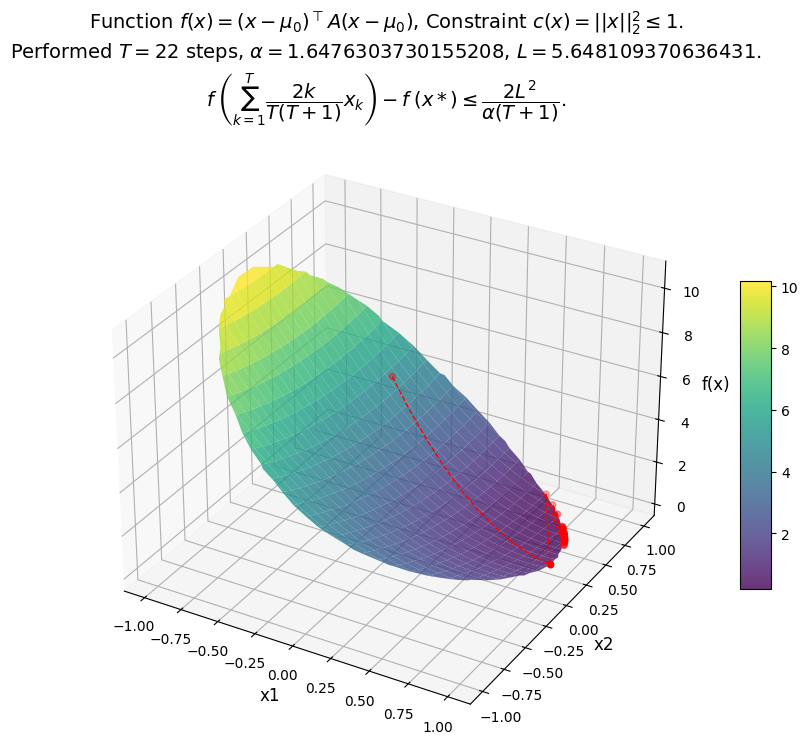

In [344]:
# Создаём сетку данных
x1 = np.linspace(-2, 2, 200)
x2 = np.linspace(-2, 2, 200)
X1, X2 = np.meshgrid(x1, x2)

# Вычисляем функцию для каждой точки сетки
Z = np.zeros_like(X1)
for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
        x = np.array([X1[i,j], X2[i,j]])
        if constraint(x) > 1:
            Z[i,j] = None
            X1[i,j] = None
            X2[i,j] = None
            continue
        Z[i,j] = f(x)

# Строим 3D график
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d', computed_zorder=False)
surf = ax.plot_surface(X1, X2, Z, cmap='viridis', alpha=0.8)

ax.plot(better_history[:,0], better_history[:,1], better_history[:,2], 'r--', linewidth=1)
ax.scatter(history[:,0], history[:,1], history[:,2], c='r', marker='o')

# Настройка отображения
ax.set_xlabel('x1', fontsize=12)
ax.set_ylabel('x2', fontsize=12)
ax.set_zlabel('f(x)', fontsize=12)

function_descr = r'Function $f(x) = (x - \mu_0)^\top A(x - \mu_0)$'
constraint_descr = r'Constraint $c(x) = ||x||^2_2 \leq 1$'
steps_descr = f'Performed $T={T}$ steps'
constants_descr = rf'$\alpha={alpha}$, $L={L}$'
convergence_descr = r'$f\;\left(\sum^T_{k=1}\dfrac{2k}{T(T + 1)}x_k \right)-f\;(x*) \leq \dfrac{2L^2}{\alpha(T + 1)}$'

ax.set_title(f'{function_descr}, {constraint_descr}.\n{steps_descr}, {constants_descr}.\n{convergence_descr}.', fontsize=14)
plt.colorbar(surf, shrink=0.5, aspect=10)

plt.show()

#### Запуски с разными m

In [394]:
def do_exps(div_m, eps, T):
    results_iters = defaultdict(list)
    results_time = defaultdict(list)
    results_operations = defaultdict(list)

    for exp in tqdm(test_cases.experiments):
        A = exp.A
        n = A.shape[0]
        mu = np.ones(n)
        if isinstance(div_m, int):
            m = n // div_m
        else:
            m = 1

        f = partial(function, A=A, mu=mu)
        grad_f = partial(stohastic_grad_function, A=A, mu=mu, m=m)

        solver_f = partial(exact_search_cvxpy, A=A, mu=mu)

        L = get_Lipschitz_constant(A)
        alpha = get_str_cvx_constant(A)

        exp.result = grad_descent(f, grad_f, solver_f, partial(nu, alpha=alpha), exp.x, T=T, eps=eps)

        results_iters[n].append(exp.result.iterations)
        results_time[n].append(exp.result.time)
        
    return results_iters, results_time

In [395]:
test_cases = TestCases(range(10, 101, 10), 10, 10)

100%|██████████| 10/10 [00:00<00:00, 94.19it/s]


m = n

In [396]:
results_iters, results_time = do_exps(div_m=1, eps=0.1, T=8000)
for n in results_iters.keys():
    print(f'[n={n}] avg iters = {np.mean(results_iters[n])}    avg time = {np.mean(results_time[n])}')

100%|██████████| 1000/1000 [07:09<00:00,  2.33it/s]

[n=10] avg iters = 239.71    avg time = 0.00429189920425415
[n=20] avg iters = 845.01    avg time = 0.023744568824768067
[n=30] avg iters = 2466.34    avg time = 0.09754499912261963
[n=40] avg iters = 2519.0    avg time = 0.14063063621520996
[n=50] avg iters = 6290.47    avg time = 0.4099478030204773
[n=60] avg iters = 4385.72    avg time = 0.33545044898986814
[n=70] avg iters = 7461.14    avg time = 0.6547762393951416
[n=80] avg iters = 8000.0    avg time = 0.7843303036689758
[n=90] avg iters = 7174.31    avg time = 0.7677244734764099
[n=100] avg iters = 7573.03    avg time = 0.8842570924758911


m = n / 2

In [ ]:
results_iters, results_time = do_exps(div_m=2, eps=0.1, T=8000)
for n in results_iters.keys():
    print(f'[n={n}] avg iters = {np.mean(results_iters[n])}    avg time = {np.mean(results_time[n])}')

100%|██████████| 1000/1000 [02:26<00:00,  6.84it/s]

[n=10] avg iters = 327.54    avg time = 0.004201586246490478
[n=20] avg iters = 1545.24    avg time = 0.0253596830368042
[n=30] avg iters = 3365.08    avg time = 0.06934371709823609
[n=40] avg iters = 4202.53    avg time = 0.11494351148605347
[n=50] avg iters = 4082.88    avg time = 0.12722506999969482
[n=60] avg iters = 3722.01    avg time = 0.1389344787597656
[n=70] avg iters = 4317.44    avg time = 0.18041930198669434
[n=80] avg iters = 4177.4    avg time = 0.1908246421813965
[n=90] avg iters = 4220.91    avg time = 0.20869673728942872
[n=100] avg iters = 4601.47    avg time = 0.24678507328033447


m = n / 4

In [ ]:
results_iters, results_time = do_exps(div_m=4, eps=0.1, T=8000)
for n in results_iters.keys():
    print(f'[n={n}] avg iters = {np.mean(results_iters[n])}    avg time = {np.mean(results_time[n])}')

100%|██████████| 1000/1000 [01:50<00:00,  9.03it/s]

[n=10] avg iters = 738.6    avg time = 0.007763381004333496
[n=20] avg iters = 3012.1    avg time = 0.03809311389923096
[n=30] avg iters = 4802.93    avg time = 0.06845034837722778
[n=40] avg iters = 4830.39    avg time = 0.0946020245552063
[n=50] avg iters = 4512.71    avg time = 0.09517330408096314
[n=60] avg iters = 3960.88    avg time = 0.09315558910369873
[n=70] avg iters = 4847.6    avg time = 0.12196056365966797
[n=80] avg iters = 4514.57    avg time = 0.12428890466690064
[n=90] avg iters = 4961.59    avg time = 0.1446816396713257
[n=100] avg iters = 4697.92    avg time = 0.15009895324707032


m = n / 8

In [397]:
results_iters, results_time = do_exps(div_m=8, eps=0.1, T=8000)
for n in results_iters.keys():
    print(f'[n={n}] avg iters = {np.mean(results_iters[n])}    avg time = {np.mean(results_time[n])}')

100%|██████████| 1000/1000 [02:28<00:00,  6.72it/s]

[n=10] avg iters = 2465.05    avg time = 0.020691392421722413
[n=20] avg iters = 5759.95    avg time = 0.05436760187149048
[n=30] avg iters = 6737.96    avg time = 0.07124826669692993
[n=40] avg iters = 7161.09    avg time = 0.10852973699569703
[n=50] avg iters = 8000.0    avg time = 0.13094116926193236
[n=60] avg iters = 7641.38    avg time = 0.14126172304153442
[n=70] avg iters = 8000.0    avg time = 0.15638162851333617
[n=80] avg iters = 8000.0    avg time = 0.17416208267211913
[n=90] avg iters = 8000.0    avg time = 0.18527331352233886
[n=100] avg iters = 8000.0    avg time = 0.19780431747436522


m = 1

In [398]:
results_iters, results_time = do_exps(div_m='n', eps=0.1, T=8000)
for n in results_iters.keys():
    print(f'[n={n}] avg iters = {np.mean(results_iters[n])}    avg time = {np.mean(results_time[n])}')

100%|██████████| 1000/1000 [01:41<00:00,  9.82it/s]

[n=10] avg iters = 2482.52    avg time = 0.020809950828552245
[n=20] avg iters = 6804.62    avg time = 0.05647119522094726
[n=30] avg iters = 7620.74    avg time = 0.06420356512069703
[n=40] avg iters = 8000.0    avg time = 0.08224119424819946
[n=50] avg iters = 8000.0    avg time = 0.08405414581298828
[n=60] avg iters = 8000.0    avg time = 0.08594599723815918
[n=70] avg iters = 8000.0    avg time = 0.08710647821426391
[n=80] avg iters = 8000.0    avg time = 0.0915218710899353
[n=90] avg iters = 8000.0    avg time = 0.09513483762741089
[n=100] avg iters = 8000.0    avg time = 0.09818047523498535


#### Эксперименты без домножения на n 

In [402]:
def stohastic_grad_function(x: NDArray, A: NDArray, mu: NDArray, m: int) -> NDArray:
    grad_full = 2 * A.dot(x - mu)
    
    n = x.shape[0]
    stoch_grad = np.zeros_like(x)
    for j in range(m):
        i = np.random.randint(0, n)          
        stoch_grad[i] += grad_full[i]    
    return stoch_grad / m 

In [403]:
def do_exps(div_m, eps, T):
    results_iters = defaultdict(list)
    results_time = defaultdict(list)

    for exp in tqdm(test_cases.experiments):
        A = exp.A
        n = A.shape[0]
        mu = np.ones(n)
        if isinstance(div_m, int):
            m = n // div_m
        else:
            m = 1

        f = partial(function, A=A, mu=mu)
        grad_f = partial(stohastic_grad_function, A=A, mu=mu, m=m)

        solver_f = partial(exact_search_cvxpy, A=A, mu=mu)

        L = get_Lipschitz_constant(A)
        alpha = get_str_cvx_constant(A)

        exp.result = grad_descent(f, grad_f, solver_f, partial(nu, alpha=alpha), exp.x, T=T, eps=eps)

        results_iters[n].append(exp.result.iterations)
        results_time[n].append(exp.result.time)
        
    return results_iters, results_time

m=n

In [404]:
results_iters, results_time = do_exps(div_m=1, eps=0.1, T=8000)
for n in results_iters.keys():
    print(f'[n={n}] avg iters = {np.mean(results_iters[n])}    avg time = {np.mean(results_time[n])}')

100%|██████████| 1000/1000 [01:04<00:00, 15.56it/s]

[n=10] avg iters = 44.64    avg time = 0.0007993507385253906
[n=20] avg iters = 76.73    avg time = 0.002381439208984375
[n=30] avg iters = 145.92    avg time = 0.0054585814476013185
[n=40] avg iters = 116.51    avg time = 0.006294734477996826
[n=50] avg iters = 351.18    avg time = 0.022427325248718263
[n=60] avg iters = 504.4    avg time = 0.03695317983627319
[n=70] avg iters = 608.25    avg time = 0.050867624282836914
[n=80] avg iters = 1690.64    avg time = 0.158004949092865
[n=90] avg iters = 815.08    avg time = 0.08486096143722534
[n=100] avg iters = 1552.28    avg time = 0.1819406795501709


m=n/2


In [405]:
results_iters, results_time = do_exps(div_m=2, eps=0.1, T=8000)
for n in results_iters.keys():
    print(f'[n={n}] avg iters = {np.mean(results_iters[n])}    avg time = {np.mean(results_time[n])}')

100%|██████████| 1000/1000 [01:05<00:00, 15.28it/s]

[n=10] avg iters = 84.05    avg time = 0.0010986208915710449
[n=20] avg iters = 152.99    avg time = 0.002685198783874512
[n=30] avg iters = 289.27    avg time = 0.006778514385223389
[n=40] avg iters = 234.52    avg time = 0.007528741359710694
[n=50] avg iters = 678.85    avg time = 0.02631361722946167
[n=60] avg iters = 976.36    avg time = 0.04376368522644043
[n=70] avg iters = 1201.88    avg time = 0.05987000703811646
[n=80] avg iters = 2539.08    avg time = 0.13971725225448609
[n=90] avg iters = 1567.04    avg time = 0.09507452726364135
[n=100] avg iters = 2743.3    avg time = 0.180622398853302


m=n/4

In [406]:
results_iters, results_time = do_exps(div_m=4, eps=0.1, T=8000)
for n in results_iters.keys():
    print(f'[n={n}] avg iters = {np.mean(results_iters[n])}    avg time = {np.mean(results_time[n])}')

100%|██████████| 1000/1000 [01:07<00:00, 14.85it/s]

[n=10] avg iters = 191.3    avg time = 0.0018489742279052734
[n=20] avg iters = 306.98    avg time = 0.0038850927352905274
[n=30] avg iters = 550.7    avg time = 0.008206374645233154
[n=40] avg iters = 469.07    avg time = 0.009792406558990479
[n=50] avg iters = 1424.73    avg time = 0.03388946533203125
[n=60] avg iters = 1991.02    avg time = 0.054491791725158695
[n=70] avg iters = 2328.07    avg time = 0.06851923942565918
[n=80] avg iters = 4011.57    avg time = 0.13231389045715333
[n=90] avg iters = 2442.78    avg time = 0.09125465393066406
[n=100] avg iters = 3933.36    avg time = 0.15799633979797365


m=n/8

In [407]:
results_iters, results_time = do_exps(div_m=8, eps=0.1, T=8000)
for n in results_iters.keys():
    print(f'[n={n}] avg iters = {np.mean(results_iters[n])}    avg time = {np.mean(results_time[n])}')

100%|██████████| 1000/1000 [01:06<00:00, 14.94it/s]

[n=10] avg iters = 368.29    avg time = 0.003127028942108154
[n=20] avg iters = 754.47    avg time = 0.00705873966217041
[n=30] avg iters = 1357.21    avg time = 0.01430997371673584
[n=40] avg iters = 868.32    avg time = 0.013030755519866943
[n=50] avg iters = 2779.6    avg time = 0.04483077526092529
[n=60] avg iters = 2906.24    avg time = 0.052616114616394045
[n=70] avg iters = 4130.44    avg time = 0.08009264945983886
[n=80] avg iters = 5459.91    avg time = 0.11854190587997436
[n=90] avg iters = 3439.88    avg time = 0.07933018922805786
[n=100] avg iters = 5009.71    avg time = 0.12175771951675415


m=1

In [408]:
results_iters, results_time = do_exps(div_m='n', eps=0.1, T=8000)
for n in results_iters.keys():
    print(f'[n={n}] avg iters = {np.mean(results_iters[n])}    avg time = {np.mean(results_time[n])}')

100%|██████████| 1000/1000 [01:18<00:00, 12.73it/s]

[n=10] avg iters = 370.77    avg time = 0.003074066638946533
[n=20] avg iters = 1502.28    avg time = 0.012361221313476563
[n=30] avg iters = 3566.09    avg time = 0.029698612689971923
[n=40] avg iters = 4143.08    avg time = 0.04208310604095459
[n=50] avg iters = 7191.56    avg time = 0.07469054460525512
[n=60] avg iters = 5315.69    avg time = 0.0561443305015564
[n=70] avg iters = 7860.18    avg time = 0.08522877454757691
[n=80] avg iters = 8000.0    avg time = 0.09185416460037231
[n=90] avg iters = 7634.43    avg time = 0.09147659063339234
[n=100] avg iters = 7874.31    avg time = 0.0948623514175415


#### Подсчет операций

In [411]:
test_cases = TestCases(range(10, 101, 10), 10, 10)

100%|██████████| 10/10 [00:00<00:00, 76.69it/s]


In [ ]:
def grad_function_with_counter(x: NDArray, A: NDArray, mu: NDArray) -> NDArray:
    return 2 * A @ (x - mu), (A.shape[0] * x.shape[0])

def stohastic_grad_function_with_counter(x: NDArray, A: NDArray, mu: NDArray, m: int) -> NDArray:
    grad_full = 2 * A.dot(x - mu)
    
    n = x.shape[0]
    stoch_grad = np.zeros_like(x)
    for _ in range(m):
        i = np.random.randint(0, n)          
        stoch_grad[i] += grad_full[i] * n

    return stoch_grad / m, (A.shape[0] * m)

In [ ]:
@dataclass
class GradDescentWithCounterResult:
    x: NDArray
    y: float
    time: float
    iterations: int
    accuracy: NDArray
    history: NDArray
    operations: int


def grad_descent_with_counter(f: Callable[[NDArray], NDArray],
                 grad_f: Callable[[NDArray], NDArray],
                 solver_f: Callable[[], None],
                 learning_rate: Callable[[int], float],
                 x_init: NDArray,
                 T: int = 100,
                 eps: float = 1e-4):    

    operations = []
    
    x_opt = solver_f()
    f_opt = f(x_opt)

    operations_counter = 0
    start_time = time.time()

    x = projection_operator(x_init)
    x_prev = [x]

    for k in range(1, T + 1):
        
        grad_value, ops = grad_f(x)
        y = x - learning_rate(k) * grad_value
        operations_counter += (ops + x.shape[0])
        
        x = projection_operator(y)
        x_prev.append(x.copy())

        f_cur = f(x)
        
        operations.append(operations_counter)

        if f_cur - f_opt <= eps:
            T = k
            break

    end_time = time.time();

    return GradDescentWithCounterResult(
        x=x,
        y=f(x),
        time=end_time-start_time,
        iterations=T,
        accuracy=(np.array([f(x) for x in x_prev[1:]]) - f(x_opt)) ** 2,
        history=x_prev,
        operations=operations
    )

In [415]:
def sgd_exps(m, eps, T):
    results_iters = defaultdict(list)
    results_time = defaultdict(list)
    results_operations = defaultdict(list)

    for exp in tqdm(test_cases.experiments):
        A = exp.A
        n = A.shape[0]
        mu = np.ones(n)
        if isinstance(m, int):
            m = n // m
        else:
            m = 1

        f = partial(function, A=A, mu=mu)
        grad_f = partial(stohastic_grad_function_with_counter, A=A, mu=mu, m=m)

        solver_f = partial(exact_search_cvxpy, A=A, mu=mu)

        L = get_Lipschitz_constant(A)
        alpha = get_str_cvx_constant(A)

        exp.result = grad_descent_with_counter(f, grad_f, solver_f, partial(nu, alpha=alpha), exp.x, T=T, eps=eps)

        results_iters[n].append(exp.result.iterations)
        results_time[n].append(exp.result.time)
        results_operations[n].append(exp.result.operations[-1])
        
    return results_operations
        
        
def gd_exps(eps, T):
    results_iters = defaultdict(list)
    results_time = defaultdict(list)
    results_operations = defaultdict(list)

    for exp in tqdm(test_cases.experiments):
        A = exp.A
        n = A.shape[0]
        mu = np.ones(n)

        f = partial(function, A=A, mu=mu)
        grad_f = partial(grad_function_with_counter, A=A, mu=mu)

        solver_f = partial(exact_search_cvxpy, A=A, mu=mu)

        L = get_Lipschitz_constant(A)
        alpha = get_str_cvx_constant(A)

        exp.result = grad_descent_with_counter(f, grad_f, solver_f, partial(nu, alpha=alpha), exp.x, T=T, eps=eps)

        results_iters[n].append(exp.result.iterations)
        results_time[n].append(exp.result.time)
        results_operations[n].append(exp.result.operations[-1])
        
    return results_operations

#### Эксперименты с подсчетом операций

In [416]:
n_ops = sgd_exps(m=1, eps=0.1, T=5000) #sgd with  m = n / 1

n2_ops = sgd_exps(m=2, eps=0.1, T=5000) #sgd with  m = n / 2

n4_ops = sgd_exps(m=4, eps=0.1, T=5000) #sgd with  m = n / 4

n8_ops = sgd_exps(m=8, eps=0.1, T=5000) #sgd with  m = n / 8

mn_ops = sgd_exps(m='n', eps=0.1, T=5000) #sgd with m = n / n

gd_ops = gd_exps(eps=0.1, T=5000) #grad

100%|██████████| 1000/1000 [00:14<00:00, 69.31it/s]


In [417]:
ops_dict = {'grad': [np.mean(gd_ops[n]) for n in gd_ops.keys()]}
ops_dict['sgd_with_m=n'] = [np.mean(n_ops[n]) for n in n_ops.keys()]
ops_dict['sgd_with_m=n/2'] = [np.mean(n2_ops[n]) for n in n2_ops.keys()]
ops_dict['sgd_with_m=n/4'] = [np.mean(n4_ops[n]) for n in n4_ops.keys()]
ops_dict['sgd_with_m=n/8'] = [np.mean(n8_ops[n]) for n in n8_ops.keys()]
ops_dict['sgd_with_m=1'] = [np.mean(mn_ops[n]) for n in mn_ops.keys()]

In [418]:
pd.DataFrame.from_dict(ops_dict)

,grad,sgd_with_m=n,sgd_with_m=n/2,sgd_with_m=n/4,sgd_with_m=n/8,sgd_with_m=1
0,6978.9,14844.4,11727.8,11602.6,15763.7,15075.1
1,35138.0,489825.8,499368.8,447882.8,489708.2,497919.0
2,420740.7,1646638.2,1270780.8,1061725.2,1144358.1,1136649.3
3,1082992.0,3216889.6,2419144.8,1875818.4,1929625.2,1922704.0
4,1511077.0,6528558.5,3834796.0,2529420.5,2527327.5,2525347.0
5,1398720.0,8980758.0,5544868.2,3450120.0,3300120.0,3300120.0
6,4554683.0,12360189.1,7128879.8,4350911.6,4025140.0,4025140.0
7,10961472.0,17400160.0,9600160.0,5400160.0,4800160.0,4800160.0
8,11135628.0,21358217.7,11925180.0,6525180.0,5625180.0,5625180.0
9,6818800.0,26750200.0,14500200.0,7750200.0,6500200.0,6500200.0


А теперь тоже самое без n

In [422]:
def stohastic_grad_function_with_counter(x: NDArray, A: NDArray, mu: NDArray, m: int) -> NDArray:
    grad_full = 2 * A.dot(x - mu)
    
    n = x.shape[0]
    stoch_grad = np.zeros_like(x)
    for _ in range(m):
        i = np.random.randint(0, n)          
        stoch_grad[i] += grad_full[i]

    return stoch_grad / m, (A.shape[0] * m)

In [423]:
def sgd_exps(m, eps, T):
    results_iters = defaultdict(list)
    results_time = defaultdict(list)
    results_operations = defaultdict(list)

    for exp in tqdm(test_cases.experiments):
        A = exp.A
        n = A.shape[0]
        mu = np.ones(n)
        if isinstance(m, int):
            m = n // m
        else:
            m = 1

        f = partial(function, A=A, mu=mu)
        grad_f = partial(stohastic_grad_function_with_counter, A=A, mu=mu, m=m)

        solver_f = partial(exact_search_cvxpy, A=A, mu=mu)

        L = get_Lipschitz_constant(A)
        alpha = get_str_cvx_constant(A)

        exp.result = grad_descent_with_counter(f, grad_f, solver_f, partial(nu, alpha=alpha), exp.x, T=T, eps=eps)

        results_iters[n].append(exp.result.iterations)
        results_time[n].append(exp.result.time)
        results_operations[n].append(exp.result.operations[-1])
        
    return results_operations
        
        
def gd_exps(eps, T):
    results_iters = defaultdict(list)
    results_time = defaultdict(list)
    results_operations = defaultdict(list)

    for exp in tqdm(test_cases.experiments):
        A = exp.A
        n = A.shape[0]
        mu = np.ones(n)

        f = partial(function, A=A, mu=mu)
        grad_f = partial(grad_function_with_counter, A=A, mu=mu)

        solver_f = partial(exact_search_cvxpy, A=A, mu=mu)

        L = get_Lipschitz_constant(A)
        alpha = get_str_cvx_constant(A)

        exp.result = grad_descent_with_counter(f, grad_f, solver_f, partial(nu, alpha=alpha), exp.x, T=T, eps=eps)

        results_iters[n].append(exp.result.iterations)
        results_time[n].append(exp.result.time)
        results_operations[n].append(exp.result.operations[-1])
        
    return results_operations

In [424]:
n_ops = sgd_exps(m=1, eps=0.1, T=5000) #sgd with  m = n / 1

n2_ops = sgd_exps(m=2, eps=0.1, T=5000) #sgd with  m = n / 2

n4_ops = sgd_exps(m=4, eps=0.1, T=5000) #sgd with  m = n / 4

n8_ops = sgd_exps(m=8, eps=0.1, T=5000) #sgd with  m = n / 8

mn_ops = sgd_exps(m='n', eps=0.1, T=5000) #sgd with m = n / n

gd_ops = gd_exps(eps=0.1, T=5000) #grad

100%|██████████| 1000/1000 [00:14<00:00, 70.21it/s]


In [425]:
ops_dict = {'grad': [np.mean(gd_ops[n]) for n in gd_ops.keys()]}
ops_dict['sgd_with_m=n'] = [np.mean(n_ops[n]) for n in n_ops.keys()]
ops_dict['sgd_with_m=n/2'] = [np.mean(n2_ops[n]) for n in n2_ops.keys()]
ops_dict['sgd_with_m=n/4'] = [np.mean(n4_ops[n]) for n in n4_ops.keys()]
ops_dict['sgd_with_m=n/8'] = [np.mean(n8_ops[n]) for n in n8_ops.keys()]
ops_dict['sgd_with_m=1'] = [np.mean(mn_ops[n]) for n in mn_ops.keys()]

In [427]:
pd.DataFrame.from_dict(ops_dict)

,grad,sgd_with_m=n,sgd_with_m=n/2,sgd_with_m=n/4,sgd_with_m=n/8,sgd_with_m=1
0,6978.9,3062.8,2252.4,2386.4,2987.9,3163.3
1,35138.0,105188.2,90152.8,71833.2,85053.0,84426.6
2,420740.7,289871.4,266434.8,241573.8,242578.8,246808.8
3,1082992.0,520902.4,556380.4,555365.2,527494.4,520388.0
4,1511077.0,1178637.0,1292661.5,1422344.5,1420789.0,1441607.5
5,1398720.0,2037544.2,1909463.4,1740940.8,1714488.0,1680938.4
6,4554683.0,3463310.2,3050770.8,2841860.7,2812406.8,2800730.8
7,10961472.0,4748503.2,4704420.8,4329003.2,4012808.8,3981328.0
8,11135628.0,4843538.1,4997951.1,4396164.3,3959048.7,3929840.1
9,6818800.0,5647354.0,6033556.0,5584221.0,5511693.0,5438776.0


### Зависимость точности от числа арифметических операций

In [428]:
def stohastic_grad_function_with_counter(x: NDArray, A: NDArray, mu: NDArray, m: int) -> NDArray:
    grad_full = 2 * A.dot(x - mu)
    
    n = x.shape[0]
    stoch_grad = np.zeros_like(x)
    for _ in range(m):
        i = np.random.randint(0, n)          
        stoch_grad[i] += grad_full[i] * n

    return stoch_grad / m, (A.shape[0] * m)

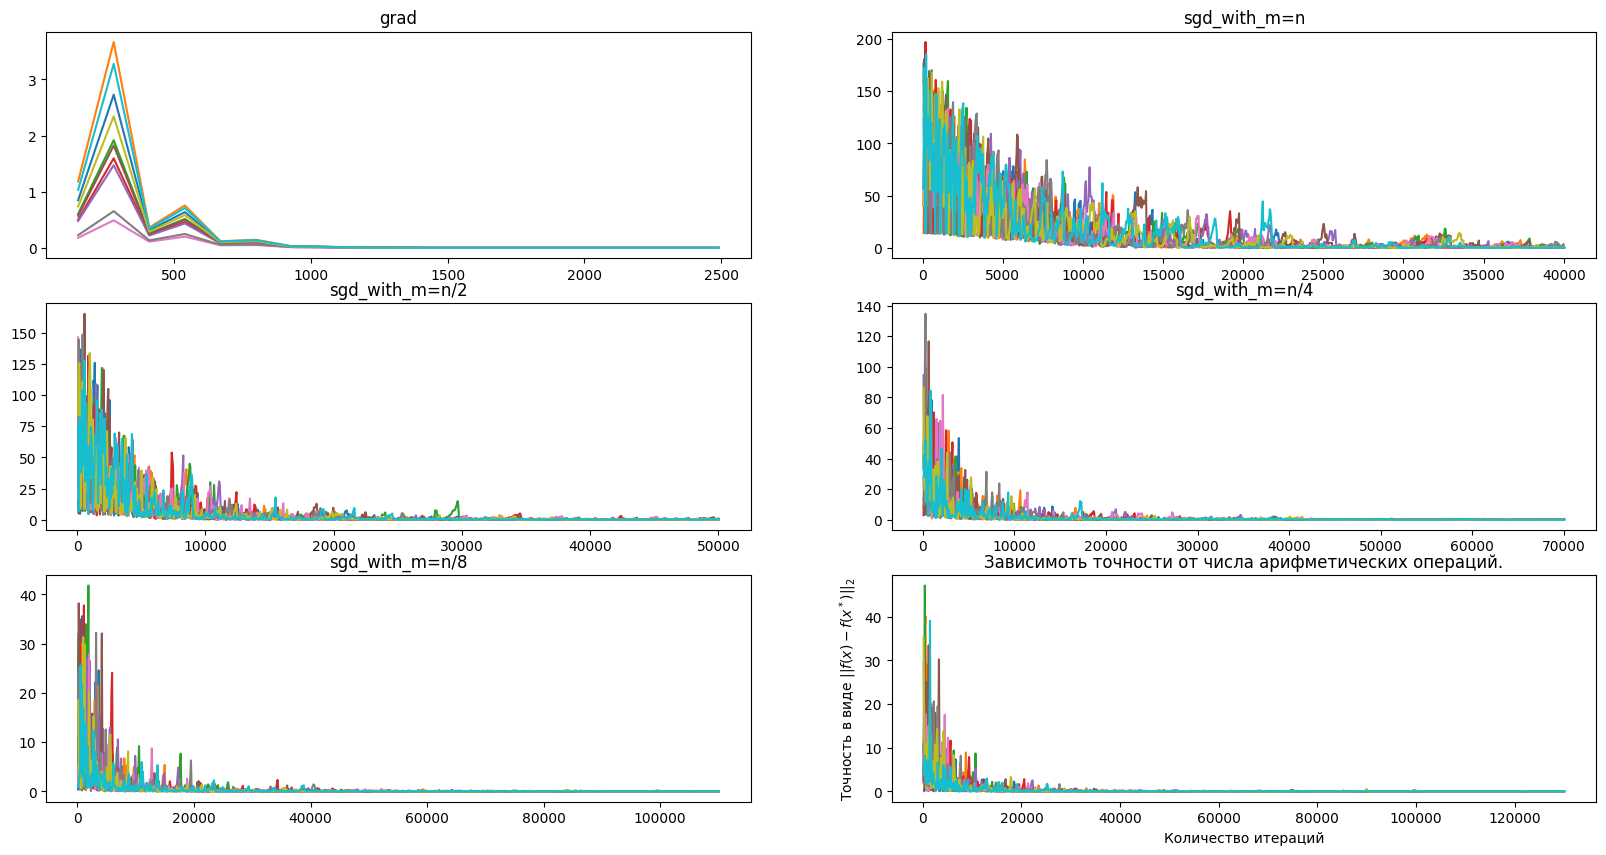

In [431]:
n = 10
A = make_spd_matrix(n)
mu = np.ones(n)

f = partial(function, A=A, mu=mu)
solver_f = partial(exact_search_cvxpy, A, mu)

L = get_Lipschitz_constant(A)
alpha = get_str_cvx_constant(A)

fix, ax = plt.subplots(3, 2, figsize=(20, 10))

for _ in range(10):

    x_init = np.random.random(n)

    gd_result = grad_descent_with_counter(f, partial(grad_function_with_counter, A=A, mu=mu), solver_f, partial(nu, alpha=alpha), x_init, T=1000, eps=1e-5)
    ax[0][0].plot(gd_result.operations, gd_result.accuracy)
    
    gd_result = grad_descent_with_counter(f, partial(stohastic_grad_function_with_counter, A=A, mu=mu, m=1), solver_f, partial(nu, alpha=alpha), x_init, T=1000, eps=1e-5)
    ax[0][1].plot(gd_result.operations, gd_result.accuracy)
    
    gd_result = grad_descent_with_counter(f, partial(stohastic_grad_function_with_counter, A=A, mu=mu, m=2), solver_f, partial(nu, alpha=alpha), x_init, T=1000, eps=1e-5)
    ax[1][0].plot(gd_result.operations, gd_result.accuracy)
    
    gd_result = grad_descent_with_counter(f, partial(stohastic_grad_function_with_counter, A=A, mu=mu, m=4), solver_f, partial(nu, alpha=alpha), x_init, T=1000, eps=1e-5)
    ax[1][1].plot(gd_result.operations, gd_result.accuracy)
    
    gd_result = grad_descent_with_counter(f, partial(stohastic_grad_function_with_counter, A=A, mu=mu, m=8), solver_f, partial(nu, alpha=alpha), x_init, T=1000, eps=1e-5)
    ax[2][0].plot(gd_result.operations, gd_result.accuracy)
    
    gd_result = grad_descent_with_counter(f, partial(stohastic_grad_function_with_counter, A=A, mu=mu, m=n), solver_f, partial(nu, alpha=alpha), x_init, T=1000, eps=1e-5)
    ax[2][1].plot(gd_result.operations, gd_result.accuracy)

			
ax[0][0].set_title("grad")
ax[0][1].set_title("sgd_with_m=n")
ax[1][0].set_title("sgd_with_m=n/2")
ax[1][1].set_title("sgd_with_m=n/4")
ax[2][0].set_title("sgd_with_m=n/8")
ax[2][1].set_title("sgd_with_m=1")

plt.title(r'Зависимоть точности от числа арифметических операций.')
plt.ylabel('Точность в виде $||f(x) - f(x^*)||_2$')
plt.xlabel('Количество итераций')
plt.show();

In [432]:
def stohastic_grad_function_with_counter(x: NDArray, A: NDArray, mu: NDArray, m: int) -> NDArray:
    grad_full = 2 * A.dot(x - mu)
    
    n = x.shape[0]
    stoch_grad = np.zeros_like(x)
    for _ in range(m):
        i = np.random.randint(0, n)          
        stoch_grad[i] += grad_full[i]

    return stoch_grad / m, (A.shape[0] * m)

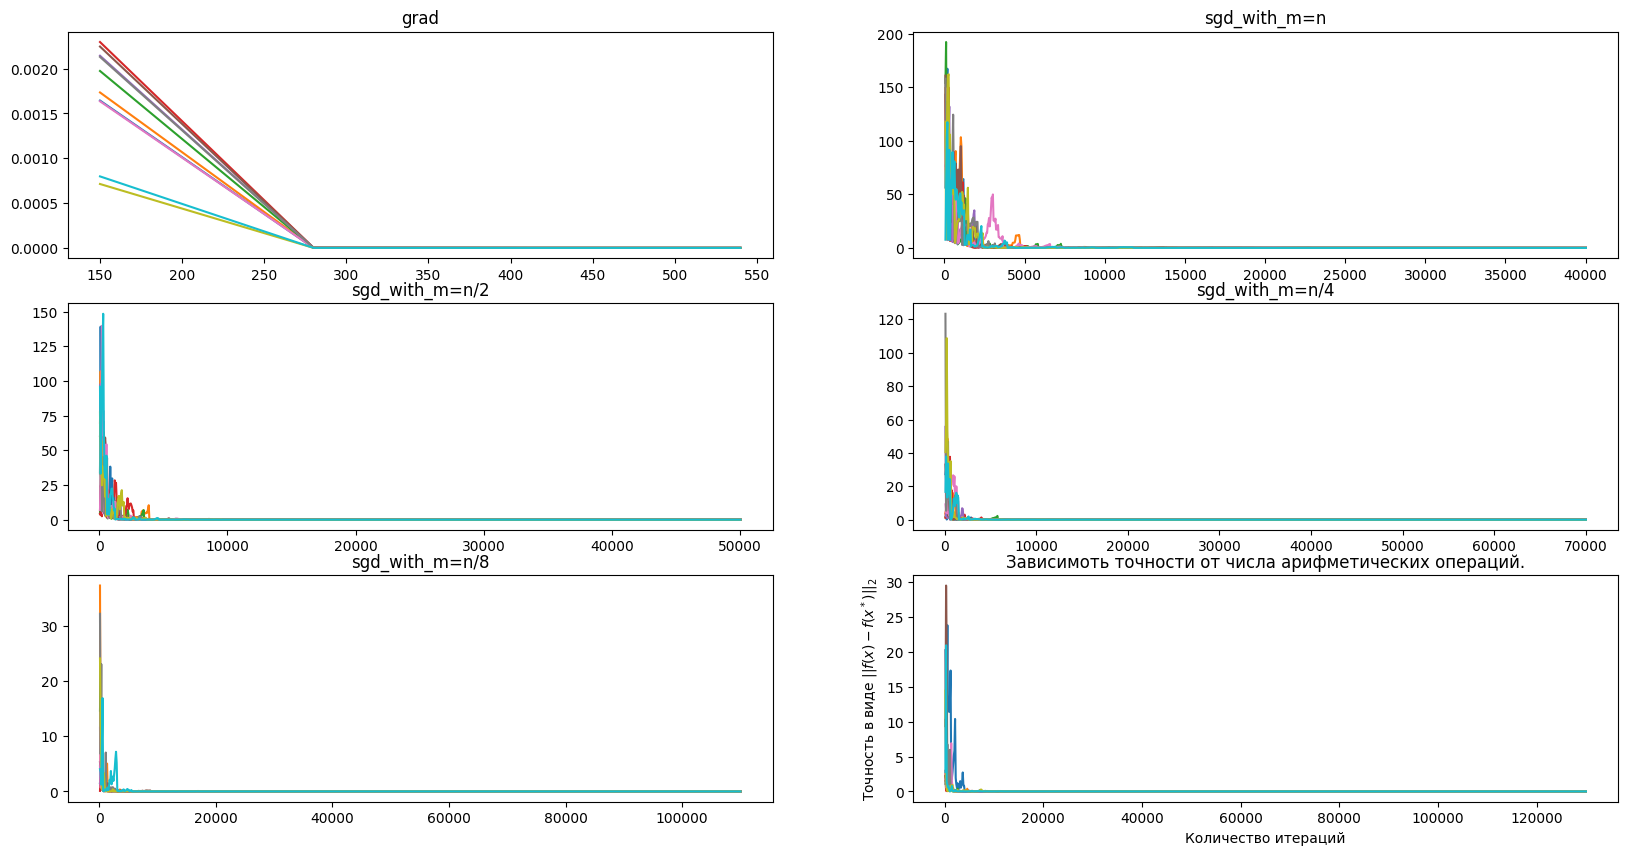

In [433]:
n = 10
A = make_spd_matrix(n)
mu = np.ones(n)

f = partial(function, A=A, mu=mu)
solver_f = partial(exact_search_cvxpy, A, mu)

L = get_Lipschitz_constant(A)
alpha = get_str_cvx_constant(A)

fix, ax = plt.subplots(3, 2, figsize=(20, 10))

for _ in range(10):

    x_init = np.random.random(n)

    gd_result = grad_descent_with_counter(f, partial(grad_function_with_counter, A=A, mu=mu), solver_f, partial(nu, alpha=alpha), x_init, T=1000, eps=1e-5)
    ax[0][0].plot(gd_result.operations, gd_result.accuracy)
    
    gd_result = grad_descent_with_counter(f, partial(stohastic_grad_function_with_counter, A=A, mu=mu, m=1), solver_f, partial(nu, alpha=alpha), x_init, T=1000, eps=1e-5)
    ax[0][1].plot(gd_result.operations, gd_result.accuracy)
    
    gd_result = grad_descent_with_counter(f, partial(stohastic_grad_function_with_counter, A=A, mu=mu, m=2), solver_f, partial(nu, alpha=alpha), x_init, T=1000, eps=1e-5)
    ax[1][0].plot(gd_result.operations, gd_result.accuracy)
    
    gd_result = grad_descent_with_counter(f, partial(stohastic_grad_function_with_counter, A=A, mu=mu, m=4), solver_f, partial(nu, alpha=alpha), x_init, T=1000, eps=1e-5)
    ax[1][1].plot(gd_result.operations, gd_result.accuracy)
    
    gd_result = grad_descent_with_counter(f, partial(stohastic_grad_function_with_counter, A=A, mu=mu, m=8), solver_f, partial(nu, alpha=alpha), x_init, T=1000, eps=1e-5)
    ax[2][0].plot(gd_result.operations, gd_result.accuracy)
    
    gd_result = grad_descent_with_counter(f, partial(stohastic_grad_function_with_counter, A=A, mu=mu, m=n), solver_f, partial(nu, alpha=alpha), x_init, T=1000, eps=1e-5)
    ax[2][1].plot(gd_result.operations, gd_result.accuracy)

			
ax[0][0].set_title("grad")
ax[0][1].set_title("sgd_with_m=n")
ax[1][0].set_title("sgd_with_m=n/2")
ax[1][1].set_title("sgd_with_m=n/4")
ax[2][0].set_title("sgd_with_m=n/8")
ax[2][1].set_title("sgd_with_m=1")

plt.title(r'Зависимоть точности от числа арифметических операций.')
plt.ylabel('Точность в виде $||f(x) - f(x^*)||_2$')
plt.xlabel('Количество итераций')
plt.show();